# CW ODMR result plots

Results from `cw_odmr_lock_in.py` (CW ODMR: continuous CH1 carrier +
chopped CH2 square wave, SR830 lock-in X/Y recorded across a frequency
sweep). Data lives under `D:/cw_odmr_lock_in`, separate from `rabi.py`'s
`D:/rabi` and `pulsed_odmr.py`'s pulsed sweeps.

## Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

DATA_DIR = "D:/cw_odmr_lock_in"

## measurement_scan (cw_odmr_lock_in.py frequency sweep) + Lorentzian fit

`chop_freq_hz=1000.0`, `sensitivity_v=2e-5`, `drive_power_dbm=0.0`. No
`reference_unlock` diagnostic is saved for this measurement type (it
predates that addition to `pulsed_odmr.py`/`rabi.py`), so all points are
used in the fit.

**Fit was flipped upside down originally**: the raw data is actually LOW
at both edges of the scan and rises to a broad elevated region in the
middle -- a PEAK, not a dip. The initial fit used a sign-ambiguous
"farthest point from the median" guess that got fooled by a single low
point near the edge, converging to an inverted, edge-anchored "dip" that
didn't match the data. Fixed: `report_lorentzian_fit()` now always
assumes a peak (`argmax(r)` as the initial center), which is the
physically correct assumption for R specifically -- it's a lock-in
MAGNITUDE (`sqrt(X^2+Y^2)`), always >= 0, so it's naturally larger near
resonance (stronger AC modulation depth) regardless of which way the
underlying fluorescence actually shifts.

measurement_scan: 97 points, 2.830000-2.849200 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=0.0


measurement_scan Lorentzian fit: f0 = 2.841289 GHz, FWHM (linewidth) = 64.0173 +/- 62.1129 MHz
[UNRELIABLE] relative uncertainty 97%, fitted FWHM is 333% of the scanned span (19.2 MHz) -- either the window doesn't fully contain both wings of the resonance, or a single Lorentzian isn't a good model for this data; widen the scan range or inspect the raw shape before trusting this number


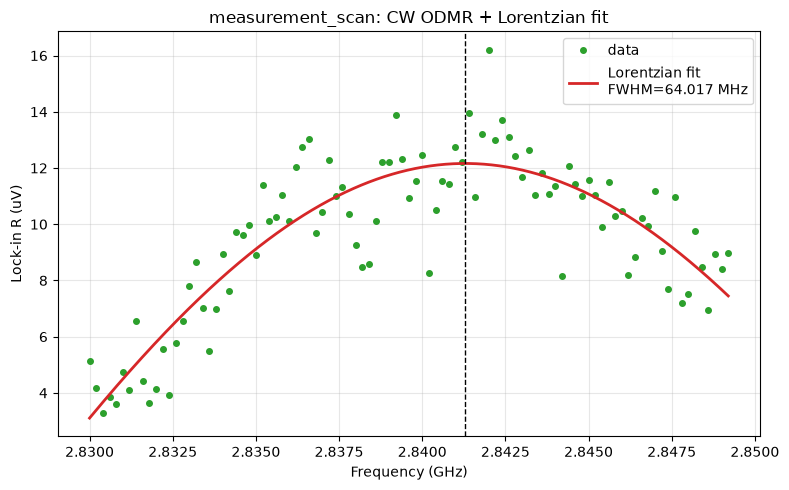

In [2]:
name_ms = "measurement_scan"
run_path_ms = f"{DATA_DIR}/{name_ms}"
freqs_ms = np.load(f"{run_path_ms}/{name_ms}_lockin_spectrum_freqs_hz.npy")
x_ms = np.load(f"{run_path_ms}/{name_ms}_lockin_spectrum_x.npy")
y_ms = np.load(f"{run_path_ms}/{name_ms}_lockin_spectrum_y.npy")
r_ms = np.sqrt(x_ms**2 + y_ms**2)

with open(f"{run_path_ms}/{name_ms}_lockin_spectrum_metadata.txt") as fh:
    metadata_text_ms = fh.read()
print(f"{name_ms}: {len(freqs_ms)} points, {freqs_ms.min()/1e9:.6f}-{freqs_ms.max()/1e9:.6f} GHz")
print(metadata_text_ms)


def lorentzian(f, f0, fwhm, amp, offset):
    """amp can be negative (dip) or positive (peak); fwhm only appears
    squared below, so curve_fit can converge to either sign -- always
    take abs(fwhm) when reporting/plotting the fitted linewidth."""
    hwhm = fwhm / 2
    return offset + amp * hwhm**2 / ((f - f0)**2 + hwhm**2)


def report_lorentzian_fit(name, freqs_ghz, r):
    """Fits r vs freqs_ghz to a single Lorentzian PEAK (not dip) -- R is a
    lock-in MAGNITUDE (sqrt(X^2+Y^2)), always >= 0, so it's naturally
    LARGER near resonance (stronger AC modulation depth) and smaller off
    resonance, regardless of the sign of the underlying fluorescence
    change. Confirmed on measurement_scan: an earlier "farthest point from
    the median" initial guess is sign-ambiguous and got fooled by a single
    low-noise point near the scan edge, converging to an inverted, edge-
    anchored "dip" that didn't match the data's actual shape (a broad
    elevated region in the middle, low at both edges) -- the initial guess
    here uses argmax(r) directly instead, assuming a peak.

    Flags the fit as unreliable if FWHM's relative uncertainty is large or
    the fitted FWHM approaches/exceeds the scanned span (signs that the
    window doesn't fully contain the lineshape, or that a single
    Lorentzian isn't a good model for this data at all)."""
    span_ghz = freqs_ghz.max() - freqs_ghz.min()
    median_r = np.median(r)
    idx_peak = np.argmax(r)
    p0 = [freqs_ghz[idx_peak], span_ghz / 4, r[idx_peak] - median_r, median_r]

    popt, pcov = curve_fit(lorentzian, freqs_ghz, r, p0=p0, maxfev=5000)
    f0_fit, fwhm_fit, amp_fit, offset_fit = popt
    fwhm_fit = abs(fwhm_fit)
    perr = np.sqrt(np.diag(pcov))
    fwhm_err = perr[1]

    rel_err = fwhm_err / fwhm_fit if fwhm_fit > 0 else np.inf
    span_fraction = fwhm_fit / span_ghz
    print(f"\n{name} Lorentzian fit: f0 = {f0_fit:.6f} GHz, "
          f"FWHM (linewidth) = {fwhm_fit*1e3:.4f} +/- {fwhm_err*1e3:.4f} MHz")
    if rel_err > 0.5 or span_fraction > 0.5:
        print(f"[UNRELIABLE] relative uncertainty {rel_err*100:.0f}%, "
              f"fitted FWHM is {span_fraction*100:.0f}% of the scanned span "
              f"({span_ghz*1e3:.1f} MHz) -- either the window doesn't fully "
              f"contain both wings of the resonance, or a single Lorentzian "
              f"isn't a good model for this data; widen the scan range or "
              f"inspect the raw shape before trusting this number")
    return f0_fit, fwhm_fit, fwhm_err, popt


freqs_ghz_ms = freqs_ms / 1e9
f0_fit_ms, fwhm_fit_ghz_ms, fwhm_err_ghz_ms, popt_ms = report_lorentzian_fit(
    name_ms, freqs_ghz_ms, r_ms)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_ms, r_ms * 1e6, "o", ms=4, color="tab:green", label="data")
freqs_fit_ms = np.linspace(freqs_ghz_ms.min(), freqs_ghz_ms.max(), 1000)
ax.plot(freqs_fit_ms, lorentzian(freqs_fit_ms, *popt_ms) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz_ms*1e3:.3f} MHz")
ax.axvline(f0_fit_ms, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_ms}: CW ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Averaged: measurement_scan_low_power + measurement_scan_low_power2 + Lorentzian fit

`drive_power_dbm=-20.0` (both repeats, vs. `measurement_scan`'s `0.0`
dBm). Same frequency grid confirmed matching exactly (101 points,
2.83-2.85 GHz), so averaged elementwise: X and Y averaged first, THEN
R = sqrt(X^2+Y^2) computed from the averaged X/Y -- not averaging R
directly, same noise-rectification-bias convention as elsewhere in this
codebase.

measurement_scan_low_power: 101 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=-20.0

measurement_scan_low_power2: 101 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=-20.0


measurement_scan_low_power (avg of 2) Lorentzian fit: f0 = 2.842228 GHz, FWHM (linewidth) = 89.0471 +/- 316.5900 MHz
[UNRELIABLE] relative uncertainty 356%, fitted FWHM is 445% of the scanned span (20.0 MHz) -- either the window doesn't fully contain both wings of the resonance, or a single Lorentzian isn't a good model for this data; widen the scan range or inspect the raw shape before trusting this number


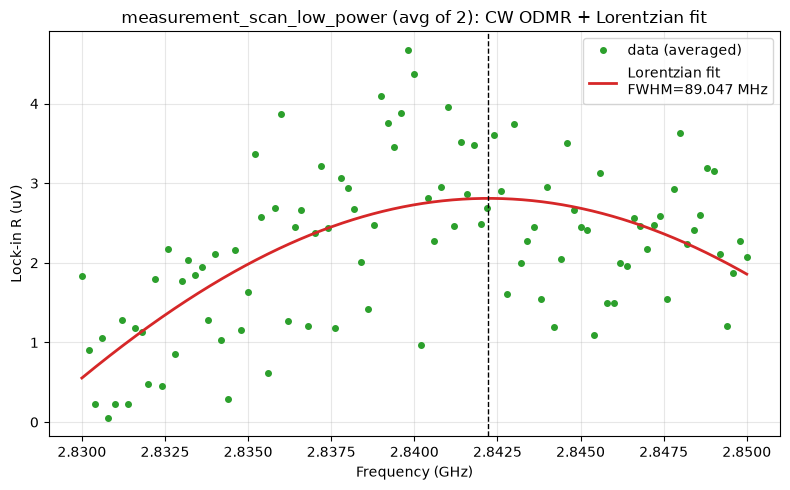

In [3]:
lp_names = ["measurement_scan_low_power", "measurement_scan_low_power2"]

lp_data = []
for name in lp_names:
    run_path = f"{DATA_DIR}/{name}"
    freqs = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    with open(f"{run_path}/{name}_lockin_spectrum_metadata.txt") as fh:
        print(f"{name}: {len(freqs)} points, {freqs.min()/1e9:.6f}-{freqs.max()/1e9:.6f} GHz")
        print(fh.read())
    lp_data.append(dict(freqs=freqs, x=x, y=y))

freqs_lp = lp_data[0]["freqs"]
assert all(np.allclose(d["freqs"], freqs_lp) for d in lp_data), \
    "frequency grids must match exactly to average elementwise"

x_avg_lp = np.mean([d["x"] for d in lp_data], axis=0)
y_avg_lp = np.mean([d["y"] for d in lp_data], axis=0)
r_avg_lp = np.sqrt(x_avg_lp**2 + y_avg_lp**2)

freqs_ghz_lp = freqs_lp / 1e9
name_lp = "measurement_scan_low_power (avg of 2)"
f0_fit_lp, fwhm_fit_ghz_lp, fwhm_err_ghz_lp, popt_lp = report_lorentzian_fit(
    name_lp, freqs_ghz_lp, r_avg_lp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_lp, r_avg_lp * 1e6, "o", ms=4, color="tab:green", label="data (averaged)")
freqs_fit_lp = np.linspace(freqs_ghz_lp.min(), freqs_ghz_lp.max(), 1000)
ax.plot(freqs_fit_lp, lorentzian(freqs_fit_lp, *popt_lp) * 1e6, "-", lw=2, color="tab:red",
        label=f"Lorentzian fit\nFWHM={fwhm_fit_ghz_lp*1e3:.3f} MHz")
ax.axvline(f0_fit_lp, color="k", ls="--", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_lp}: CW ODMR + Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## measurement_scan_dense (no fit yet)

`drive_power_dbm=-10.0`. Just the raw X/Y/R plot -- no Lorentzian fit for
now.

measurement_scan_dense: 401 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=-10.0



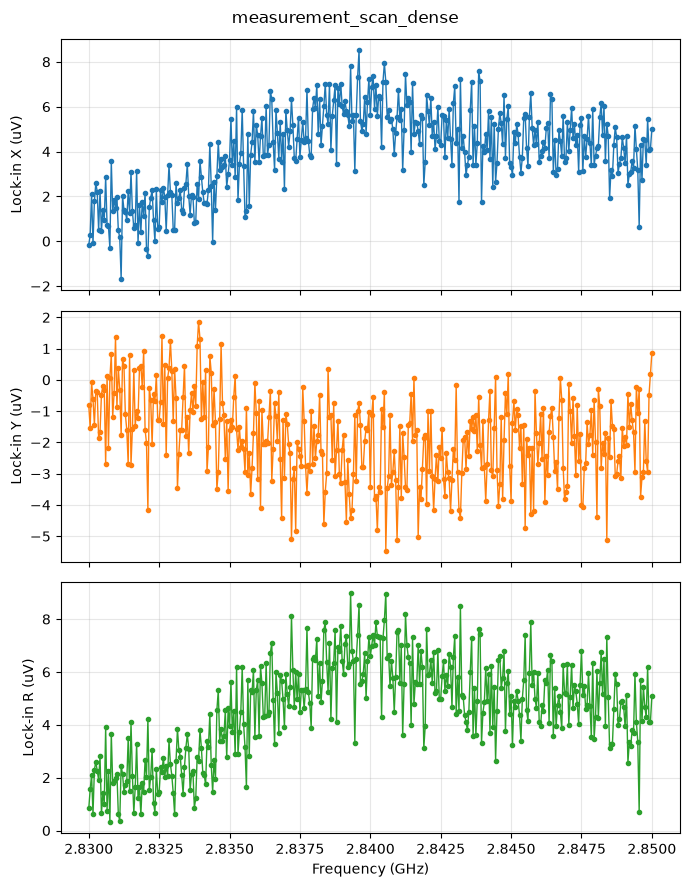

In [4]:
name_dense = "measurement_scan_dense"
run_path_dense = f"{DATA_DIR}/{name_dense}"
freqs_dense = np.load(f"{run_path_dense}/{name_dense}_lockin_spectrum_freqs_hz.npy")
x_dense = np.load(f"{run_path_dense}/{name_dense}_lockin_spectrum_x.npy")
y_dense = np.load(f"{run_path_dense}/{name_dense}_lockin_spectrum_y.npy")
r_dense = np.sqrt(x_dense**2 + y_dense**2)

with open(f"{run_path_dense}/{name_dense}_lockin_spectrum_metadata.txt") as fh:
    metadata_text_dense = fh.read()
print(f"{name_dense}: {len(freqs_dense)} points, "
      f"{freqs_dense.min()/1e9:.6f}-{freqs_dense.max()/1e9:.6f} GHz")
print(metadata_text_dense)

freqs_ghz_dense = freqs_dense / 1e9

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(freqs_ghz_dense, x_dense * 1e6, "o-", ms=3, lw=1, color="tab:blue")
axes[1].plot(freqs_ghz_dense, y_dense * 1e6, "o-", ms=3, lw=1, color="tab:orange")
axes[2].plot(freqs_ghz_dense, r_dense * 1e6, "o-", ms=3, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("Frequency (GHz)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name_dense}")
plt.tight_layout()
plt.show()

## measurement_scan_dense: double-Lorentzian fit

Sum of two independent Lorentzian peaks sharing one baseline offset.
Initial guess splits the scan range in half and uses each half's own max
as a candidate peak center -- a simple, robust starting point given how
noisy this data is (401 points, single-shot, no averaging).

Peak 1: f0 = 2.839257 GHz, FWHM = 9.8934 +/- 1.4260 MHz, amp = 5.784 uV
Peak 2: f0 = 2.847847 GHz, FWHM = 10.0344 +/- 2.9572 MHz, amp = 3.667 uV
Peak separation: 8.590 MHz
[NOTE] peak separation is smaller than the average of the two fitted widths -- the two peaks strongly overlap, and a single Lorentzian may explain this data just as well as two; take the two-peak decomposition with caution


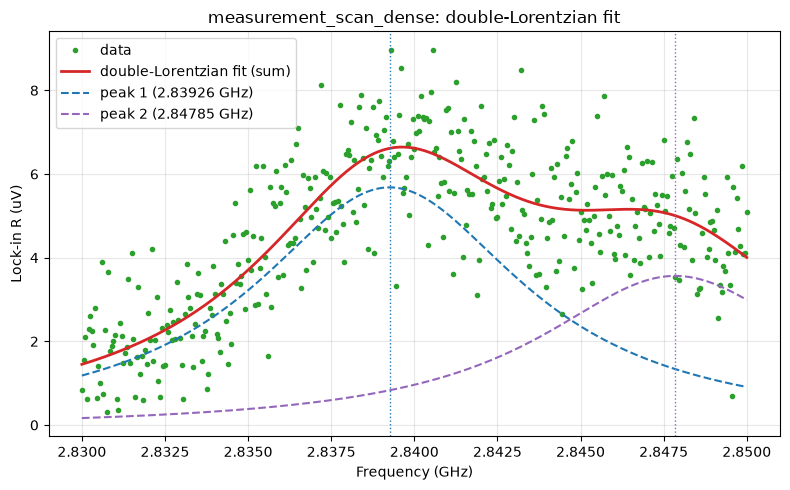

In [5]:
def double_lorentzian(f, f1, fwhm1, amp1, f2, fwhm2, amp2, offset):
    """Sum of two independent Lorentzian peaks + one shared baseline
    offset. Each fwhm only appears squared -- take abs() when reporting."""
    term1 = amp1 * (fwhm1 / 2) ** 2 / ((f - f1) ** 2 + (fwhm1 / 2) ** 2)
    term2 = amp2 * (fwhm2 / 2) ** 2 / ((f - f2) ** 2 + (fwhm2 / 2) ** 2)
    return offset + term1 + term2


mid = len(freqs_ghz_dense) // 2
left_r, right_r = r_dense[:mid], r_dense[mid:]
left_f, right_f = freqs_ghz_dense[:mid], freqs_ghz_dense[mid:]
median_r_dense = np.median(r_dense)
span_ghz_dense = freqs_ghz_dense.max() - freqs_ghz_dense.min()

idx_left = np.argmax(left_r)
idx_right = np.argmax(right_r)
p0_double = [
    left_f[idx_left], span_ghz_dense / 8, left_r[idx_left] - median_r_dense,
    right_f[idx_right], span_ghz_dense / 8, right_r[idx_right] - median_r_dense,
    median_r_dense,
]

popt_dbl, pcov_dbl = curve_fit(double_lorentzian, freqs_ghz_dense, r_dense,
                                p0=p0_double, maxfev=10000)
f1_fit, fwhm1_fit, amp1_fit, f2_fit, fwhm2_fit, amp2_fit, offset_fit = popt_dbl
fwhm1_fit, fwhm2_fit = abs(fwhm1_fit), abs(fwhm2_fit)
perr_dbl = np.sqrt(np.diag(pcov_dbl))

print(f"Peak 1: f0 = {f1_fit:.6f} GHz, FWHM = {fwhm1_fit*1e3:.4f} +/- {perr_dbl[1]*1e3:.4f} MHz, "
      f"amp = {amp1_fit*1e6:.3f} uV")
print(f"Peak 2: f0 = {f2_fit:.6f} GHz, FWHM = {fwhm2_fit*1e3:.4f} +/- {perr_dbl[4]*1e3:.4f} MHz, "
      f"amp = {amp2_fit*1e6:.3f} uV")
separation_mhz = abs(f2_fit - f1_fit) * 1e3
print(f"Peak separation: {separation_mhz:.3f} MHz")
if separation_mhz < (fwhm1_fit + fwhm2_fit) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap, and a single "
          "Lorentzian may explain this data just as well as two; take the "
          "two-peak decomposition with caution")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_dense, r_dense * 1e6, "o", ms=3, color="tab:green", label="data")
freqs_fit_dense = np.linspace(freqs_ghz_dense.min(), freqs_ghz_dense.max(), 2000)
ax.plot(freqs_fit_dense, double_lorentzian(freqs_fit_dense, *popt_dbl) * 1e6,
        "-", lw=2, color="tab:red", label="double-Lorentzian fit (sum)")
ax.plot(freqs_fit_dense,
        (offset_fit + amp1_fit * (fwhm1_fit / 2) ** 2 / ((freqs_fit_dense - f1_fit) ** 2 + (fwhm1_fit / 2) ** 2)) * 1e6,
        "--", lw=1.5, color="tab:blue", label=f"peak 1 ({f1_fit:.5f} GHz)")
ax.plot(freqs_fit_dense,
        (offset_fit + amp2_fit * (fwhm2_fit / 2) ** 2 / ((freqs_fit_dense - f2_fit) ** 2 + (fwhm2_fit / 2) ** 2)) * 1e6,
        "--", lw=1.5, color="tab:purple", label=f"peak 2 ({f2_fit:.5f} GHz)")
ax.axvline(f1_fit, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_fit, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_dense}: double-Lorentzian fit")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## measurement_scan_dense: single vs. double Lorentzian comparison

Fits a single Lorentzian to the same data and compares residual sum of
squares (RSS) and AIC (Akaike Information Criterion, penalizes the
double fit's 3 extra parameters) -- decides whether the second peak is
actually justified by the data or just fitting noise.


measurement_scan_dense Lorentzian fit: f0 = 2.842090 GHz, FWHM (linewidth) = 41.4808 +/- 13.0827 MHz
[UNRELIABLE] relative uncertainty 32%, fitted FWHM is 207% of the scanned span (20.0 MHz) -- either the window doesn't fully contain both wings of the resonance, or a single Lorentzian isn't a good model for this data; widen the scan range or inspect the raw shape before trusting this number

Single Lorentzian: RSS = 577.693 (uV^2), AIC = -10925.64
Double Lorentzian: RSS = 485.256 (uV^2), AIC = -10989.56
Double Lorentzian preferred (AIC lower by 63.92) -- the second peak earns its added complexity


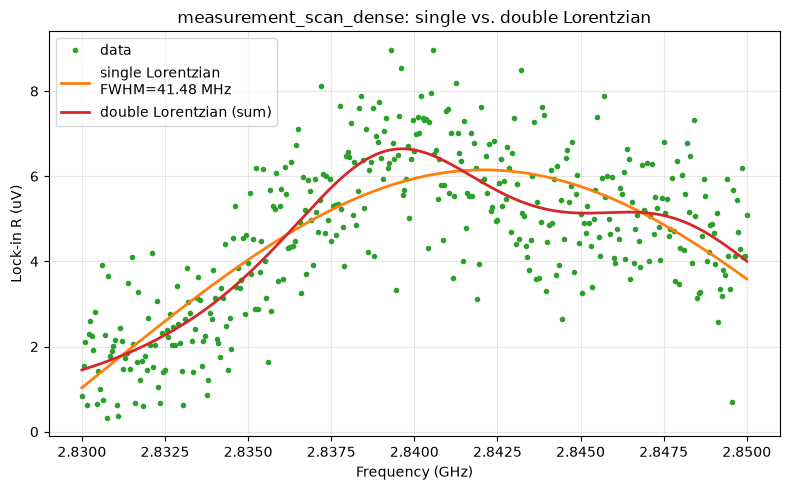

In [6]:
f0_fit_dense, fwhm_fit_ghz_dense, fwhm_err_ghz_dense, popt_single_dense = report_lorentzian_fit(
    name_dense, freqs_ghz_dense, r_dense)

n_points = len(r_dense)
resid_single = r_dense - lorentzian(freqs_ghz_dense, *popt_single_dense)
resid_double = r_dense - double_lorentzian(freqs_ghz_dense, *popt_dbl)
rss_single = np.sum(resid_single ** 2)
rss_double = np.sum(resid_double ** 2)
k_single, k_double = 4, 7  # number of free parameters in each model

# AIC = n*ln(RSS/n) + 2k -- lower is better; unlike RSS alone, this
# penalizes the double fit's extra 3 parameters, so a lower AIC for the
# double fit means it's actually earning its added complexity, not just
# fitting noise with more free knobs.
aic_single = n_points * np.log(rss_single / n_points) + 2 * k_single
aic_double = n_points * np.log(rss_double / n_points) + 2 * k_double

print(f"\nSingle Lorentzian: RSS = {rss_single*1e12:.3f} (uV^2), AIC = {aic_single:.2f}")
print(f"Double Lorentzian: RSS = {rss_double*1e12:.3f} (uV^2), AIC = {aic_double:.2f}")
if aic_double < aic_single:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single - aic_double:.2f}) "
          f"-- the second peak earns its added complexity")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double - aic_single:.2f}) "
          f"-- the second peak is NOT justified by this data; likely fitting noise")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_dense, r_dense * 1e6, "o", ms=3, color="tab:green", label="data")
freqs_fit_dense = np.linspace(freqs_ghz_dense.min(), freqs_ghz_dense.max(), 2000)
ax.plot(freqs_fit_dense, lorentzian(freqs_fit_dense, *popt_single_dense) * 1e6,
        "-", lw=2, color="tab:orange",
        label=f"single Lorentzian\nFWHM={fwhm_fit_ghz_dense*1e3:.2f} MHz")
ax.plot(freqs_fit_dense, double_lorentzian(freqs_fit_dense, *popt_dbl) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_dense}: single vs. double Lorentzian")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Averaged: measurement_scan_dense + measurement_scan_dense2, single vs. double Lorentzian

Remeasurement of `measurement_scan_dense` (same params, `drive_power_dbm
=-10.0`) as `measurement_scan_dense2` -- frequency grid confirmed
matching exactly (401 points), so averaged elementwise (X/Y averaged
first, then R from the averaged X/Y). Refits both single and double
Lorentzians on the averaged, less noisy data and reruns the AIC
comparison to see if the two-peak structure holds up now that half the
noise has been beaten down. (`measurement_scan_dense3` also exists but is
empty -- not included.)

measurement_scan_dense: 401 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=-10.0

measurement_scan_dense2: 401 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=-10.0


measurement_scan_dense (avg of 2) Lorentzian fit: f0 = 2.842233 GHz, FWHM (linewidth) = 49.3529 +/- 14.3182 MHz
[UNRELIABLE] relative uncertainty 29%, fitted FWHM is 247% of the scanned span (20.0 MHz) -- either the window doesn't fully contain both wings of the resonance, or a single Lorentzian isn't a good model for this data; widen the scan range or inspect the raw shape before trusting this number

Double fit peak 1: f0 = 2.838997 GHz, FWHM = 10.3363 +/- 1.2382 MHz, amp = 5.610 uV
Double fit peak 2: f0 = 2.847530 GHz, FWHM = 11.3123 +/- 2.3728 MHz, amp = 4.108 uV
Peak separation: 8.533 M

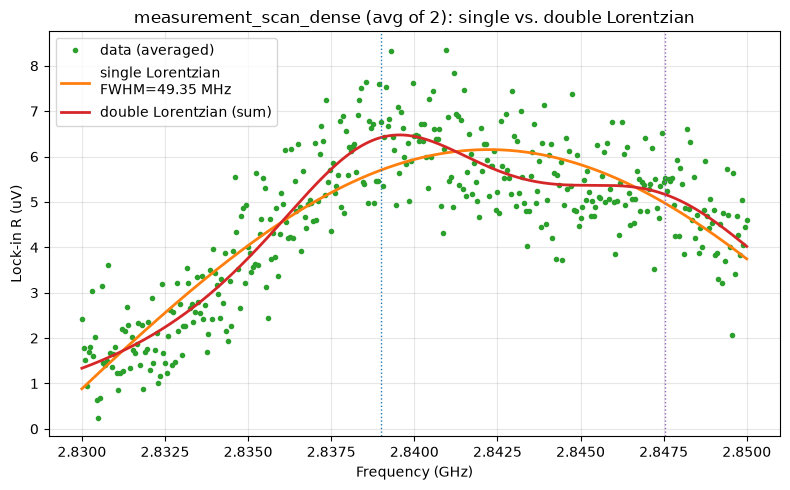

In [7]:
dense_names = ["measurement_scan_dense", "measurement_scan_dense2"]

dense_data = []
for name in dense_names:
    run_path = f"{DATA_DIR}/{name}"
    freqs = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    with open(f"{run_path}/{name}_lockin_spectrum_metadata.txt") as fh:
        print(f"{name}: {len(freqs)} points, {freqs.min()/1e9:.6f}-{freqs.max()/1e9:.6f} GHz")
        print(fh.read())
    dense_data.append(dict(freqs=freqs, x=x, y=y))

freqs_dense_avg = dense_data[0]["freqs"]
assert all(np.allclose(d["freqs"], freqs_dense_avg) for d in dense_data), \
    "frequency grids must match exactly to average elementwise"

x_avg_dense = np.mean([d["x"] for d in dense_data], axis=0)
y_avg_dense = np.mean([d["y"] for d in dense_data], axis=0)
r_avg_dense = np.sqrt(x_avg_dense**2 + y_avg_dense**2)
freqs_ghz_dense_avg = freqs_dense_avg / 1e9
name_dense_avg = "measurement_scan_dense (avg of 2)"

# Single fit
f0_fit_da, fwhm_fit_ghz_da, fwhm_err_ghz_da, popt_single_da = report_lorentzian_fit(
    name_dense_avg, freqs_ghz_dense_avg, r_avg_dense)

# Double fit -- same left/right-half initial guess strategy as before
mid_da = len(freqs_ghz_dense_avg) // 2
left_r_da, right_r_da = r_avg_dense[:mid_da], r_avg_dense[mid_da:]
left_f_da, right_f_da = freqs_ghz_dense_avg[:mid_da], freqs_ghz_dense_avg[mid_da:]
median_r_da = np.median(r_avg_dense)
span_ghz_da = freqs_ghz_dense_avg.max() - freqs_ghz_dense_avg.min()
idx_left_da = np.argmax(left_r_da)
idx_right_da = np.argmax(right_r_da)
p0_double_da = [
    left_f_da[idx_left_da], span_ghz_da / 8, left_r_da[idx_left_da] - median_r_da,
    right_f_da[idx_right_da], span_ghz_da / 8, right_r_da[idx_right_da] - median_r_da,
    median_r_da,
]
popt_dbl_da, pcov_dbl_da = curve_fit(double_lorentzian, freqs_ghz_dense_avg, r_avg_dense,
                                      p0=p0_double_da, maxfev=10000)
f1_da, fwhm1_da, amp1_da, f2_da, fwhm2_da, amp2_da, offset_da = popt_dbl_da
fwhm1_da, fwhm2_da = abs(fwhm1_da), abs(fwhm2_da)
perr_dbl_da = np.sqrt(np.diag(pcov_dbl_da))

print(f"\nDouble fit peak 1: f0 = {f1_da:.6f} GHz, FWHM = {fwhm1_da*1e3:.4f} +/- "
      f"{perr_dbl_da[1]*1e3:.4f} MHz, amp = {amp1_da*1e6:.3f} uV")
print(f"Double fit peak 2: f0 = {f2_da:.6f} GHz, FWHM = {fwhm2_da*1e3:.4f} +/- "
      f"{perr_dbl_da[4]*1e3:.4f} MHz, amp = {amp2_da*1e6:.3f} uV")
separation_mhz_da = abs(f2_da - f1_da) * 1e3
print(f"Peak separation: {separation_mhz_da:.3f} MHz")
if separation_mhz_da < (fwhm1_da + fwhm2_da) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap")

# AIC comparison, same as the single-scan version
n_points_da = len(r_avg_dense)
rss_single_da = np.sum((r_avg_dense - lorentzian(freqs_ghz_dense_avg, *popt_single_da)) ** 2)
rss_double_da = np.sum((r_avg_dense - double_lorentzian(freqs_ghz_dense_avg, *popt_dbl_da)) ** 2)
aic_single_da = n_points_da * np.log(rss_single_da / n_points_da) + 2 * 4
aic_double_da = n_points_da * np.log(rss_double_da / n_points_da) + 2 * 7
print(f"\nSingle Lorentzian: RSS = {rss_single_da*1e12:.3f} (uV^2), AIC = {aic_single_da:.2f}")
print(f"Double Lorentzian: RSS = {rss_double_da*1e12:.3f} (uV^2), AIC = {aic_double_da:.2f}")
if aic_double_da < aic_single_da:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single_da - aic_double_da:.2f})")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double_da - aic_single_da:.2f}) "
          f"-- the second peak is NOT justified on the averaged data")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_dense_avg, r_avg_dense * 1e6, "o", ms=3, color="tab:green", label="data (averaged)")
freqs_fit_da = np.linspace(freqs_ghz_dense_avg.min(), freqs_ghz_dense_avg.max(), 2000)
ax.plot(freqs_fit_da, lorentzian(freqs_fit_da, *popt_single_da) * 1e6,
        "-", lw=2, color="tab:orange",
        label=f"single Lorentzian\nFWHM={fwhm_fit_ghz_da*1e3:.2f} MHz")
ax.plot(freqs_fit_da, double_lorentzian(freqs_fit_da, *popt_dbl_da) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.axvline(f1_da, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_da, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_dense_avg}: single vs. double Lorentzian")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## measurement_scan_dense3: single vs. double Lorentzian (separate, not averaged)

`drive_power_dbm=-20.0` -- a DIFFERENT power than `measurement_scan_dense`/
`measurement_scan_dense2`'s `-10.0`, so plotted/fit on its own rather than
averaged in with them.

measurement_scan_dense3: 401 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=-20.0


measurement_scan_dense3 Lorentzian fit: f0 = 2.842476 GHz, FWHM (linewidth) = 31.2331 +/- 16.2823 MHz
[UNRELIABLE] relative uncertainty 52%, fitted FWHM is 156% of the scanned span (20.0 MHz) -- either the window doesn't fully contain both wings of the resonance, or a single Lorentzian isn't a good model for this data; widen the scan range or inspect the raw shape before trusting this number

Double fit peak 1: f0 = 2.840390 GHz, FWHM = 8.4555 +/- 2.0044 MHz, amp = 1.960 uV
Double fit peak 2: f0 = 2.847933 GHz, FWHM = 3.5530 +/- 1.3370 MHz, amp = 1.193 uV
Peak separation: 7.543 MHz

Single Lorentzian: RSS = 417.923 (uV^2), AIC = -11055.46
Double Lorentzian: RSS = 398.514 (uV^2), AIC = -11068.53
Double Lorentzian preferred (AIC lower by 13.07)


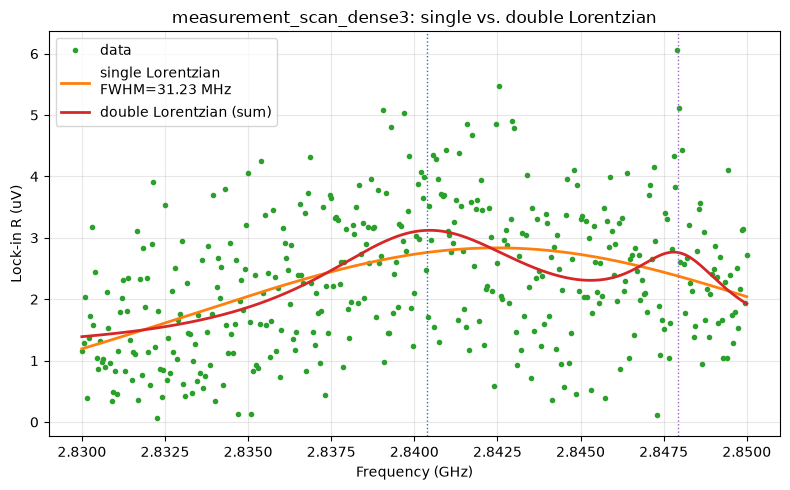

In [8]:
name_d3 = "measurement_scan_dense3"
run_path_d3 = f"{DATA_DIR}/{name_d3}"
freqs_d3 = np.load(f"{run_path_d3}/{name_d3}_lockin_spectrum_freqs_hz.npy")
x_d3 = np.load(f"{run_path_d3}/{name_d3}_lockin_spectrum_x.npy")
y_d3 = np.load(f"{run_path_d3}/{name_d3}_lockin_spectrum_y.npy")
r_d3 = np.sqrt(x_d3**2 + y_d3**2)

with open(f"{run_path_d3}/{name_d3}_lockin_spectrum_metadata.txt") as fh:
    metadata_text_d3 = fh.read()
print(f"{name_d3}: {len(freqs_d3)} points, {freqs_d3.min()/1e9:.6f}-{freqs_d3.max()/1e9:.6f} GHz")
print(metadata_text_d3)

freqs_ghz_d3 = freqs_d3 / 1e9

# Single fit
f0_fit_d3, fwhm_fit_ghz_d3, fwhm_err_ghz_d3, popt_single_d3 = report_lorentzian_fit(
    name_d3, freqs_ghz_d3, r_d3)

# Double fit -- same left/right-half initial guess strategy as before
mid_d3 = len(freqs_ghz_d3) // 2
left_r_d3, right_r_d3 = r_d3[:mid_d3], r_d3[mid_d3:]
left_f_d3, right_f_d3 = freqs_ghz_d3[:mid_d3], freqs_ghz_d3[mid_d3:]
median_r_d3 = np.median(r_d3)
span_ghz_d3 = freqs_ghz_d3.max() - freqs_ghz_d3.min()
idx_left_d3 = np.argmax(left_r_d3)
idx_right_d3 = np.argmax(right_r_d3)
p0_double_d3 = [
    left_f_d3[idx_left_d3], span_ghz_d3 / 8, left_r_d3[idx_left_d3] - median_r_d3,
    right_f_d3[idx_right_d3], span_ghz_d3 / 8, right_r_d3[idx_right_d3] - median_r_d3,
    median_r_d3,
]
popt_dbl_d3, pcov_dbl_d3 = curve_fit(double_lorentzian, freqs_ghz_d3, r_d3,
                                      p0=p0_double_d3, maxfev=10000)
f1_d3, fwhm1_d3, amp1_d3, f2_d3, fwhm2_d3, amp2_d3, offset_d3 = popt_dbl_d3
fwhm1_d3, fwhm2_d3 = abs(fwhm1_d3), abs(fwhm2_d3)
perr_dbl_d3 = np.sqrt(np.diag(pcov_dbl_d3))

print(f"\nDouble fit peak 1: f0 = {f1_d3:.6f} GHz, FWHM = {fwhm1_d3*1e3:.4f} +/- "
      f"{perr_dbl_d3[1]*1e3:.4f} MHz, amp = {amp1_d3*1e6:.3f} uV")
print(f"Double fit peak 2: f0 = {f2_d3:.6f} GHz, FWHM = {fwhm2_d3*1e3:.4f} +/- "
      f"{perr_dbl_d3[4]*1e3:.4f} MHz, amp = {amp2_d3*1e6:.3f} uV")
separation_mhz_d3 = abs(f2_d3 - f1_d3) * 1e3
print(f"Peak separation: {separation_mhz_d3:.3f} MHz")
if separation_mhz_d3 < (fwhm1_d3 + fwhm2_d3) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap")

# AIC comparison
n_points_d3 = len(r_d3)
rss_single_d3 = np.sum((r_d3 - lorentzian(freqs_ghz_d3, *popt_single_d3)) ** 2)
rss_double_d3 = np.sum((r_d3 - double_lorentzian(freqs_ghz_d3, *popt_dbl_d3)) ** 2)
aic_single_d3 = n_points_d3 * np.log(rss_single_d3 / n_points_d3) + 2 * 4
aic_double_d3 = n_points_d3 * np.log(rss_double_d3 / n_points_d3) + 2 * 7
print(f"\nSingle Lorentzian: RSS = {rss_single_d3*1e12:.3f} (uV^2), AIC = {aic_single_d3:.2f}")
print(f"Double Lorentzian: RSS = {rss_double_d3*1e12:.3f} (uV^2), AIC = {aic_double_d3:.2f}")
if aic_double_d3 < aic_single_d3:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single_d3 - aic_double_d3:.2f})")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double_d3 - aic_single_d3:.2f}) "
          f"-- the second peak is NOT justified on this data")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_d3, r_d3 * 1e6, "o", ms=3, color="tab:green", label="data")
freqs_fit_d3 = np.linspace(freqs_ghz_d3.min(), freqs_ghz_d3.max(), 2000)
ax.plot(freqs_fit_d3, lorentzian(freqs_fit_d3, *popt_single_d3) * 1e6,
        "-", lw=2, color="tab:orange",
        label=f"single Lorentzian\nFWHM={fwhm_fit_ghz_d3*1e3:.2f} MHz")
ax.plot(freqs_fit_d3, double_lorentzian(freqs_fit_d3, *popt_dbl_d3) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.axvline(f1_d3, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_d3, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_d3}: single vs. double Lorentzian")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Averaged: measurement_scan_dense3 + measurement_scan_dense4, single vs. double Lorentzian

Same `drive_power_dbm=-20.0` (`measurement_scan_dense4` used a finer
`sensitivity_v=1e-5` vs. `dense3`'s `2e-5` -- only affects resolution/
noise floor, not the returned physical X/Y values, so still safe to
average). Frequency grid confirmed matching exactly (401 points).

measurement_scan_dense3: 401 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=2e-05
phase_deg=0.0
drive_power_dbm=-20.0

measurement_scan_dense4: 401 points, 2.830000-2.850000 GHz
chop_freq_hz=1000.0
chop_duty_pct=50.0
time_constant_s=0.1
settle_time_constants=5.0
sensitivity_v=1e-05
phase_deg=0.0
drive_power_dbm=-20.0


measurement_scan_dense3 (avg of 2) Lorentzian fit: f0 = 2.842364 GHz, FWHM (linewidth) = 29.8232 +/- 9.7975 MHz
[UNRELIABLE] relative uncertainty 33%, fitted FWHM is 149% of the scanned span (20.0 MHz) -- either the window doesn't fully contain both wings of the resonance, or a single Lorentzian isn't a good model for this data; widen the scan range or inspect the raw shape before trusting this number

Double fit peak 1: f0 = 2.840387 GHz, FWHM = 9.7460 +/- 1.8119 MHz, amp = 2.338 uV
Double fit peak 2: f0 = 2.847952 GHz, FWHM = 4.6701 +/- 1.5677 MHz, amp = 1.221 uV
Peak separation: 7.565 MH

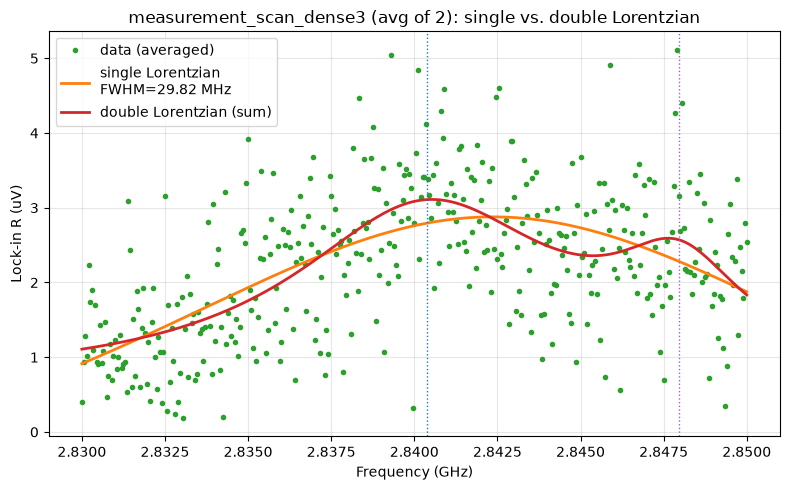

In [9]:
d34_names = ["measurement_scan_dense3", "measurement_scan_dense4"]

d34_data = []
for name in d34_names:
    run_path = f"{DATA_DIR}/{name}"
    freqs = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    with open(f"{run_path}/{name}_lockin_spectrum_metadata.txt") as fh:
        print(f"{name}: {len(freqs)} points, {freqs.min()/1e9:.6f}-{freqs.max()/1e9:.6f} GHz")
        print(fh.read())
    d34_data.append(dict(freqs=freqs, x=x, y=y))

freqs_d34 = d34_data[0]["freqs"]
assert all(np.allclose(d["freqs"], freqs_d34) for d in d34_data), \
    "frequency grids must match exactly to average elementwise"

x_avg_d34 = np.mean([d["x"] for d in d34_data], axis=0)
y_avg_d34 = np.mean([d["y"] for d in d34_data], axis=0)
r_avg_d34 = np.sqrt(x_avg_d34**2 + y_avg_d34**2)
freqs_ghz_d34 = freqs_d34 / 1e9
name_d34 = "measurement_scan_dense3 (avg of 2)"

# Single fit
f0_fit_d34, fwhm_fit_ghz_d34, fwhm_err_ghz_d34, popt_single_d34 = report_lorentzian_fit(
    name_d34, freqs_ghz_d34, r_avg_d34)

# Double fit -- same left/right-half initial guess strategy as before
mid_d34 = len(freqs_ghz_d34) // 2
left_r_d34, right_r_d34 = r_avg_d34[:mid_d34], r_avg_d34[mid_d34:]
left_f_d34, right_f_d34 = freqs_ghz_d34[:mid_d34], freqs_ghz_d34[mid_d34:]
median_r_d34 = np.median(r_avg_d34)
span_ghz_d34 = freqs_ghz_d34.max() - freqs_ghz_d34.min()
idx_left_d34 = np.argmax(left_r_d34)
idx_right_d34 = np.argmax(right_r_d34)
p0_double_d34 = [
    left_f_d34[idx_left_d34], span_ghz_d34 / 8, left_r_d34[idx_left_d34] - median_r_d34,
    right_f_d34[idx_right_d34], span_ghz_d34 / 8, right_r_d34[idx_right_d34] - median_r_d34,
    median_r_d34,
]
popt_dbl_d34, pcov_dbl_d34 = curve_fit(double_lorentzian, freqs_ghz_d34, r_avg_d34,
                                        p0=p0_double_d34, maxfev=10000)
f1_d34, fwhm1_d34, amp1_d34, f2_d34, fwhm2_d34, amp2_d34, offset_d34 = popt_dbl_d34
fwhm1_d34, fwhm2_d34 = abs(fwhm1_d34), abs(fwhm2_d34)
perr_dbl_d34 = np.sqrt(np.diag(pcov_dbl_d34))

print(f"\nDouble fit peak 1: f0 = {f1_d34:.6f} GHz, FWHM = {fwhm1_d34*1e3:.4f} +/- "
      f"{perr_dbl_d34[1]*1e3:.4f} MHz, amp = {amp1_d34*1e6:.3f} uV")
print(f"Double fit peak 2: f0 = {f2_d34:.6f} GHz, FWHM = {fwhm2_d34*1e3:.4f} +/- "
      f"{perr_dbl_d34[4]*1e3:.4f} MHz, amp = {amp2_d34*1e6:.3f} uV")
separation_mhz_d34 = abs(f2_d34 - f1_d34) * 1e3
print(f"Peak separation: {separation_mhz_d34:.3f} MHz")
if separation_mhz_d34 < (fwhm1_d34 + fwhm2_d34) * 1e3 / 2:
    print("[NOTE] peak separation is smaller than the average of the two "
          "fitted widths -- the two peaks strongly overlap")

# AIC comparison
n_points_d34 = len(r_avg_d34)
rss_single_d34 = np.sum((r_avg_d34 - lorentzian(freqs_ghz_d34, *popt_single_d34)) ** 2)
rss_double_d34 = np.sum((r_avg_d34 - double_lorentzian(freqs_ghz_d34, *popt_dbl_d34)) ** 2)
aic_single_d34 = n_points_d34 * np.log(rss_single_d34 / n_points_d34) + 2 * 4
aic_double_d34 = n_points_d34 * np.log(rss_double_d34 / n_points_d34) + 2 * 7
print(f"\nSingle Lorentzian: RSS = {rss_single_d34*1e12:.3f} (uV^2), AIC = {aic_single_d34:.2f}")
print(f"Double Lorentzian: RSS = {rss_double_d34*1e12:.3f} (uV^2), AIC = {aic_double_d34:.2f}")
if aic_double_d34 < aic_single_d34:
    print(f"Double Lorentzian preferred (AIC lower by {aic_single_d34 - aic_double_d34:.2f})")
else:
    print(f"Single Lorentzian preferred (AIC lower by {aic_double_d34 - aic_single_d34:.2f}) "
          f"-- the second peak is NOT justified on the averaged data")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_ghz_d34, r_avg_d34 * 1e6, "o", ms=3, color="tab:green", label="data (averaged)")
freqs_fit_d34 = np.linspace(freqs_ghz_d34.min(), freqs_ghz_d34.max(), 2000)
ax.plot(freqs_fit_d34, lorentzian(freqs_fit_d34, *popt_single_d34) * 1e6,
        "-", lw=2, color="tab:orange",
        label=f"single Lorentzian\nFWHM={fwhm_fit_ghz_d34*1e3:.2f} MHz")
ax.plot(freqs_fit_d34, double_lorentzian(freqs_fit_d34, *popt_dbl_d34) * 1e6,
        "-", lw=2, color="tab:red", label="double Lorentzian (sum)")
ax.axvline(f1_d34, color="tab:blue", ls=":", lw=1)
ax.axvline(f2_d34, color="tab:purple", ls=":", lw=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in R (uV)")
ax.set_title(f"{name_d34}: single vs. double Lorentzian")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()